In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df1 = pd.read_csv("BOWLING STATS - IPL_2022.csv")

In [25]:
df1.head()

,POS,Player,Mat,Inns,Ov,Runs,Wkts,BBI,Avg,Econ,SR,4w,5w
0,1,Yuzvendra Chahal,17,17,68.0,527,27,40/5,19.51,7.75,15.11,1,1
1,2,Wanindu Hasaranga,16,16,57.0,430,26,18/5,16.53,7.54,13.15,1,1
2,3,Kagiso Rabada,13,13,48.0,406,23,33/4,17.65,8.45,12.52,2,0
3,4,Umran Malik,14,14,49.1,444,22,25/5,20.18,9.03,13.40,1,1
4,5,Kuldeep Yadav,14,14,49.4,419,21,14/4,19.95,8.43,14.19,2,0


In [26]:
df1.shape

(103, 13)

In [27]:
df1.fillna(value=0,inplace=True)
print(df1)

     POS             Player  Mat  Inns    Ov  Runs  Wkts   BBI    Avg   Econ  \
0      1   Yuzvendra Chahal   17    17  68.0   527    27  40/5  19.51   7.75   
1      2  Wanindu Hasaranga   16    16  57.0   430    26  18/5  16.53   7.54   
2      3      Kagiso Rabada   13    13  48.0   406    23  33/4  17.65   8.45   
3      4        Umran Malik   14    14  49.1   444    22  25/5  20.18   9.03   
4      5      Kuldeep Yadav   14    14  49.4   419    21  14/4  19.95   8.43   
..   ...                ...  ...   ...   ...   ...   ...   ...    ...    ...   
98    99      Shreyas Gopal    1     1   3.0    34     1  34/1  34.00  11.33   
99   100       Fabian Allen    1     1   4.0    46     1  46/1  46.00  11.50   
100  101        Sean Abbott    1     1   4.0    47     1  47/1  47.00  11.75   
101  102        Riyan Parag   17     4   4.0    59     1  12/1  59.00  14.75   
102  103      Dewald Brevis    7     1   0.3     8     1   8/1   8.00  16.00   

        SR  4w  5w  
0    15.11   1   1

<Axes: xlabel='Wkts', ylabel='Count'>

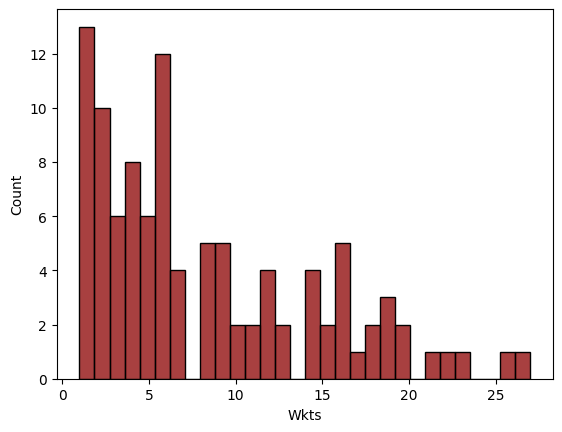

In [28]:
sns.histplot(df1['Wkts'].dropna(), color='darkred', bins=30)

<Axes: >

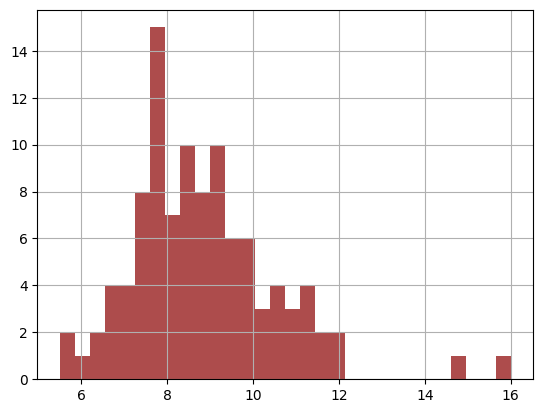

In [29]:
df1['Econ'].hist(bins=30,color='darkred',alpha=0.7)

<Axes: >

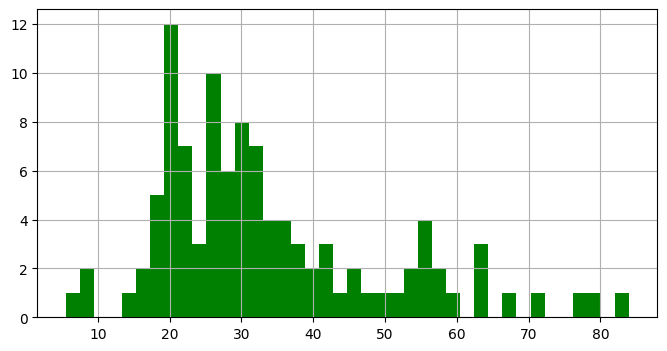

In [30]:
df1['Avg'].hist(color='green',bins=40,figsize=(8,4))

In [31]:
x = df1[['Mat','Inns','Ov','Runs','Avg','Econ','SR','4w','5w']]
y = df1['Wkts']

In [32]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)

In [33]:
x_train.shape, x_test.shape

((82, 9), (21, 9))

In [34]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error

# Change to regressor
knn = KNeighborsRegressor(n_neighbors=1)
knn.fit(x_train, y_train)

# Predict
y_pred = knn.predict(x_test)

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error (MAE):", mae)


Mean Absolute Error (MAE): 1.8095238095238095


In [35]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

# Use regressor instead of classifier
dtree = DecisionTreeRegressor()
dtree.fit(x_train, y_train)

# Predict
predictions = dtree.predict(x_test)

# Calculate MAE
mae = mean_absolute_error(y_test, predictions)
print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 1.7142857142857142


In [36]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Use regressor instead of classifier
rfc = RandomForestRegressor(n_estimators=100, random_state=42)
rfc.fit(x_train, y_train)

# Predict
rfc_pred = rfc.predict(x_test)

# Calculate MAE
mae = mean_absolute_error(y_test, rfc_pred)
print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 0.8800000000000002


In [37]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error

svr = SVR()
svr.fit(x_train, y_train)
y_pred_svr = svr.predict(x_test)

mae = mean_absolute_error(y_test, y_pred_svr)
print("MAE:", mae)


MAE: 2.258905887841596


In [38]:
import xgboost as xgb
xgb_train = xgb.DMatrix(x_train, y_train, enable_categorical=True)
xgb_test = xgb.DMatrix(x_test, y_test, enable_categorical=True)

In [39]:
n=50
params = {'objective': 'reg:squarederror','max_depth': 3,'learning_rate': 0.1,}
model = xgb.train(params=params,dtrain=xgb_train,num_boost_round=n)

In [40]:
preds = model.predict(xgb_test)
print(preds)

[11.157189   6.1619015 21.94154    5.321644   4.345786   3.1899548
 14.714223   4.3078957  5.736418   6.9309473  7.019334   1.1720929
  1.8407778 14.169895  19.905933  10.087181  13.752372  11.890764
 10.704287  19.443205   7.8574615]


In [41]:
preds=preds.astype(int)
print(preds)

[11  6 21  5  4  3 14  4  5  6  7  1  1 14 19 10 13 11 10 19  7]


In [42]:
from sklearn.metrics import mean_absolute_error

# MAE
mae = mean_absolute_error(y_test, preds)
print("Mean Absolute Error (MAE):", mae)


Mean Absolute Error (MAE): 0.7619047619047619


In [43]:
bowling_columns = ['Mat', 'Inns', 'Ov', 'Runs', 'Avg', 'Econ', 'SR', '4w', '5w']
custom_input = pd.DataFrame([[12, 12, 46, 360, 24.0, 7.8, 18.4, 1, 0]], columns=bowling_columns)
custom_dmatrix = xgb.DMatrix(custom_input)
prediction = model.predict(custom_dmatrix)
print("Predicted Wickets:", prediction[0])

Predicted Wickets: 16.071344
